The metadata used for computation is shown below

/tmp/ipykernel_3175108/2784634934.py:104: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ax.get_yticks(), fontsize=font_size)


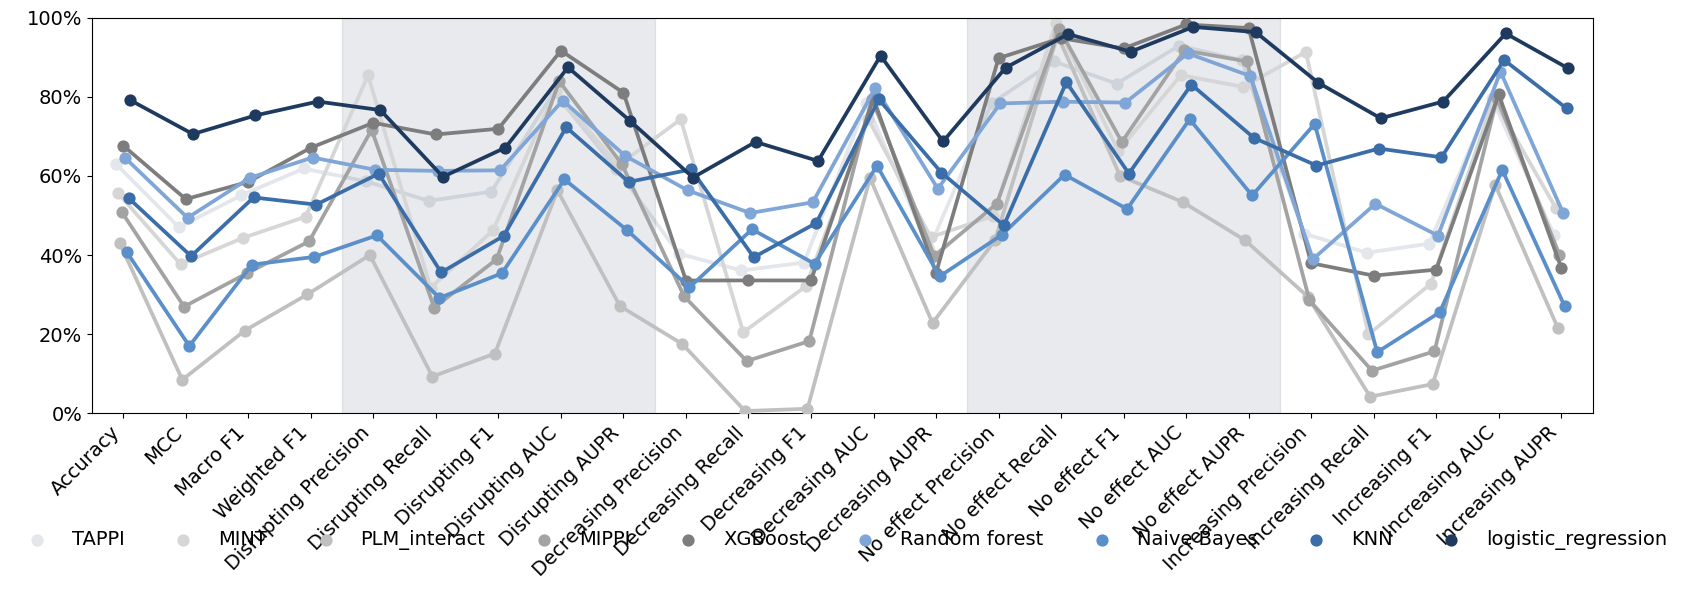

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

font_size = 14

models = [
    "logistic_regression", "KNN", "Naive Bayes", "Random forest",
    "XGBoost", "MIPPI", "PLM_interact", "MINT", "TAPPI"
][::-1]

categories = [
    "Accuracy", "MCC", "Macro F1", "Weighted F1",
    "Disrupting Precision", "Disrupting Recall", "Disrupting F1", "Disrupting AUC", "Disrupting AUPR",
    "Decreasing Precision", "Decreasing Recall", "Decreasing F1", "Decreasing AUC", "Decreasing AUPR",
    "No effect Precision", "No effect Recall", "No effect F1", "No effect AUC", "No effect AUPR",
    "Increasing Precision", "Increasing Recall", "Increasing F1", "Increasing AUC", "Increasing AUPR"
]

data = [
    [
        0.7911, 0.7055, 0.7526, 0.7877,
        0.7661, 0.5976, 0.6714, 0.8741, 0.7379,
        0.5958, 0.6857, 0.6376, 0.9034, 0.6869,
        0.8731, 0.9581, 0.9136, 0.9763, 0.9631,
        0.8352, 0.7454, 0.7878, 0.9597, 0.8714
    ],
    [
        0.5439, 0.3971, 0.5455, 0.5273,
        0.6055, 0.3560, 0.4484, 0.7227, 0.5847,
        0.6163, 0.3944, 0.4810, 0.7931, 0.6084,
        0.4747, 0.8366, 0.6057, 0.8306, 0.6959,
        0.6261, 0.6690, 0.6469, 0.8928, 0.7707
    ],
    [
        0.4074, 0.1701, 0.3758, 0.3953,
        0.4497, 0.2917, 0.3539, 0.5910, 0.4630,
        0.3183, 0.4649, 0.3779, 0.6255, 0.3459,
        0.4514, 0.6030, 0.5163, 0.7429, 0.5504,
        0.7313, 0.1546, 0.2552, 0.6149, 0.2701
    ],
    [
        0.6455, 0.4940, 0.5953, 0.6463,
        0.6153, 0.6126, 0.6140, 0.7903, 0.6505,
        0.5633, 0.5061, 0.5332, 0.8221, 0.5676,
        0.7829, 0.7873, 0.7851, 0.9093, 0.8521,
        0.3896, 0.5296, 0.4490, 0.8631, 0.5068
    ],
    [
        0.6761, 0.5411, 0.5849, 0.6711,
        0.7340, 0.7045, 0.7190, 0.9163, 0.8099,
        0.3356, 0.3359, 0.3358, 0.7949, 0.3551,
        0.8973, 0.9478, 0.9218, 0.9824, 0.9733,
        0.3795, 0.3480, 0.3631, 0.8056, 0.3677
    ],
    [
        0.5096, 0.2696, 0.3535, 0.4345,
        0.7164, 0.2673, 0.3893, 0.8389, 0.6302,
        0.2954, 0.1321, 0.1826, 0.7946, 0.3977,
        0.5297, 0.9711, 0.6855, 0.9168, 0.8891,
        0.2860, 0.1079, 0.1567, 0.7960, 0.4006
    ],
    [
        0.4301, 0.0849, 0.2092, 0.3005,
        0.4000, 0.0931, 0.1510, 0.5633, 0.2711,
        0.1750, 0.0060, 0.0117, 0.5944, 0.2283,
        0.4373, 0.9552, 0.5999, 0.5340, 0.4371,
        0.2952, 0.0423, 0.0740, 0.5772, 0.2165
    ],
    [
        0.5564, 0.3767, 0.4434, 0.4967,
        0.8539, 0.3173, 0.4627, 0.8154, 0.6263,
        0.7429, 0.2047, 0.3209, 0.7435, 0.4449,
        0.4990, 0.9859, 0.6626, 0.8544, 0.8246,
        0.9130, 0.1995, 0.3274, 0.7935, 0.5181
    ],
    [
        0.6293, 0.4703, 0.5507, 0.6186,
        0.5858, 0.5367, 0.5602, 0.8122, 0.6169,
        0.4035, 0.3610, 0.3810, 0.7831, 0.4155,
        0.7833, 0.8889, 0.8328, 0.9289, 0.8922,
        0.4541, 0.4059, 0.4286, 0.7962, 0.4505
    ]
][::-1]

df = pd.DataFrame(data, columns=categories, index=models).reset_index()
df = df.melt(id_vars="index", var_name="Category", value_name="Score")
df.rename(columns={"index": "Model"}, inplace=True)

palette = [
    "#1f3a5f", "#3b6ea8", "#5b8fc9", "#7fa6d6",
    "#7d7d7d", "#a3a3a3", "#c0c0c0", "#d6d6d6", "#e3e6ea"
][::-1]

fig, ax = plt.subplots(figsize=(18, 6))

# Order by our custom categories
sns.pointplot(x="Category", y="Score", hue="Model", data=df, order=categories,
              dodge=True, palette=palette, ax=ax)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=font_size)
ax.set_yticklabels(ax.get_yticks(), fontsize=font_size)

n_models = len(models)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=n_models, frameon=False, fontsize=font_size)

plt.subplots_adjust(bottom=0.4)
ax.set_xlabel('', fontsize=font_size)
ax.set_ylabel('', fontsize=font_size)

def to_percent(y, _):
    return f'{y*100:.0f}%'


x_positions = range(len(categories))
ax.axvspan(x_positions[4]-0.5, x_positions[8]+0.5, color="#1f3a5f", alpha=0.1)
ax.axvspan(x_positions[14]-0.5, x_positions[18]+0.5, color="#1f3a5f", alpha=0.1)
ax.set_xlim(-0.5, len(categories) - 0.5)
ax.yaxis.set_major_formatter(FuncFormatter(to_percent))
ax.set_ylim(0, 1)

plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'

# plt.tight_layout()
plt.savefig(
    "old_seq.svg",
    format="svg",
    bbox_inches="tight"
)
plt.show()
plt.close()

Download results

In [17]:
import requests
import zipfile
import io
import os

url = "https://figshare.com/ndownloader/files/63458643"

response = requests.get(url)
response.raise_for_status() 

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    z.extractall(os.getcwd())

print("Download and extraction complete.")

HTTPError: 403 Client Error: Forbidden for url: https://figshare.com/ndownloader/files/63458643

TAPPI result

In [1]:
import pickle
from sklearn.metrics import (
    accuracy_score, matthews_corrcoef,
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import label_binarize

file_path = 'tappi_results_traditional.pkl'
with open(file_path, "rb") as f:
    data = pickle.load(f)

y_test = data["y_test"]
y_pred = data["y_pred"]
y_proba = data["y_proba"]
class_names = ['Disrupting', 'Decreasing', 'No effect', 'Increasing']

accuracy = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

y_test_bin = label_binarize(y_test, classes=range(len(class_names)))
results = {}
for i, name in enumerate(class_names):
    precision = precision_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    aupr = average_precision_score(y_test_bin[:, i], y_proba[:, i])

    results[name] = {
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc,
        "AUPR": aupr
    }

print(f"Accuracy: {accuracy:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}\n")

for name in class_names:
    print(f"{name} Precision: {results[name]['Precision']:.4f}")
    print(f"{name} Recall: {results[name]['Recall']:.4f}")
    print(f"{name} F1: {results[name]['F1']:.4f}")
    print(f"{name} AUC: {results[name]['AUC']:.4f}")
    print(f"{name} AUPR: {results[name]['AUPR']:.4f}\n")

Accuracy: 0.7911
MCC: 0.7055
Macro F1: 0.7526
Weighted F1: 0.7877

Disrupting Precision: 0.7661
Disrupting Recall: 0.5976
Disrupting F1: 0.6714
Disrupting AUC: 0.8741
Disrupting AUPR: 0.7379

Decreasing Precision: 0.5958
Decreasing Recall: 0.6857
Decreasing F1: 0.6376
Decreasing AUC: 0.9034
Decreasing AUPR: 0.6869

No effect Precision: 0.8731
No effect Recall: 0.9581
No effect F1: 0.9136
No effect AUC: 0.9763
No effect AUPR: 0.9631

Increasing Precision: 0.8352
Increasing Recall: 0.7454
Increasing F1: 0.7878
Increasing AUC: 0.9597
Increasing AUPR: 0.8714



In [8]:
import pickle
from sklearn.metrics import (
    accuracy_score, matthews_corrcoef,
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import label_binarize

file_path = 'mippi_results.pkl'
with open(file_path, "rb") as f:
    data = pickle.load(f)

y_test = data["y_test"]
y_pred = data["y_pred"]
y_proba = data["y_proba"]
class_names = ['Disrupting', 'Decreasing', 'No effect', 'Increasing']

accuracy = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

y_test_bin = label_binarize(y_test, classes=range(len(class_names)))
results = {}
for i, name in enumerate(class_names):
    precision = precision_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    aupr = average_precision_score(y_test_bin[:, i], y_proba[:, i])

    results[name] = {
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc,
        "AUPR": aupr
    }

print(f"Accuracy: {accuracy:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}\n")

for name in class_names:
    print(f"{name} Precision: {results[name]['Precision']:.4f}")
    print(f"{name} Recall: {results[name]['Recall']:.4f}")
    print(f"{name} F1: {results[name]['F1']:.4f}")
    print(f"{name} AUC: {results[name]['AUC']:.4f}")
    print(f"{name} AUPR: {results[name]['AUPR']:.4f}\n")

Accuracy: 0.6455
MCC: 0.4940
Macro F1: 0.5953
Weighted F1: 0.6463

Disrupting Precision: 0.6153
Disrupting Recall: 0.6126
Disrupting F1: 0.6140
Disrupting AUC: 0.7903
Disrupting AUPR: 0.6505

Decreasing Precision: 0.5633
Decreasing Recall: 0.5061
Decreasing F1: 0.5332
Decreasing AUC: 0.8221
Decreasing AUPR: 0.5676

No effect Precision: 0.7829
No effect Recall: 0.7873
No effect F1: 0.7851
No effect AUC: 0.9093
No effect AUPR: 0.8521

Increasing Precision: 0.3896
Increasing Recall: 0.5296
Increasing F1: 0.4490
Increasing AUC: 0.8631
Increasing AUPR: 0.5068



In [9]:
import pickle
from sklearn.metrics import (
    accuracy_score, matthews_corrcoef,
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import label_binarize

file_path = 'mint_results_traditional.pkl'
with open(file_path, "rb") as f:
    data = pickle.load(f)

y_test = data["y_test"]
y_pred = data["y_pred"]
y_proba = data["y_proba"]
class_names = ['Disrupting', 'Decreasing', 'No effect', 'Increasing']

accuracy = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

y_test_bin = label_binarize(y_test, classes=range(len(class_names)))
results = {}
for i, name in enumerate(class_names):
    precision = precision_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    aupr = average_precision_score(y_test_bin[:, i], y_proba[:, i])

    results[name] = {
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc,
        "AUPR": aupr
    }

print(f"Accuracy: {accuracy:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}\n")

for name in class_names:
    print(f"{name} Precision: {results[name]['Precision']:.4f}")
    print(f"{name} Recall: {results[name]['Recall']:.4f}")
    print(f"{name} F1: {results[name]['F1']:.4f}")
    print(f"{name} AUC: {results[name]['AUC']:.4f}")
    print(f"{name} AUPR: {results[name]['AUPR']:.4f}\n")

Accuracy: 0.5439
MCC: 0.3971
Macro F1: 0.5455
Weighted F1: 0.5273

Disrupting Precision: 0.6055
Disrupting Recall: 0.3560
Disrupting F1: 0.4484
Disrupting AUC: 0.7227
Disrupting AUPR: 0.5847

Decreasing Precision: 0.6163
Decreasing Recall: 0.3944
Decreasing F1: 0.4810
Decreasing AUC: 0.7931
Decreasing AUPR: 0.6084

No effect Precision: 0.4747
No effect Recall: 0.8366
No effect F1: 0.6057
No effect AUC: 0.8306
No effect AUPR: 0.6959

Increasing Precision: 0.6261
Increasing Recall: 0.6690
Increasing F1: 0.6469
Increasing AUC: 0.8928
Increasing AUPR: 0.7707



In [11]:
import pickle
from sklearn.metrics import (
    accuracy_score, matthews_corrcoef,
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import label_binarize

file_path = 'PLM_interact_results_traditional.pkl'
with open(file_path, "rb") as f:
    data = pickle.load(f)

y_test = data["y_test"]
y_pred = data["y_pred"]
y_proba = data["y_proba"]
class_names = ['Disrupting', 'Decreasing', 'No effect', 'Increasing']

accuracy = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

y_test_bin = label_binarize(y_test, classes=range(len(class_names)))
results = {}
for i, name in enumerate(class_names):
    precision = precision_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    aupr = average_precision_score(y_test_bin[:, i], y_proba[:, i])

    results[name] = {
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc,
        "AUPR": aupr
    }

print(f"Accuracy: {accuracy:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}\n")

for name in class_names:
    print(f"{name} Precision: {results[name]['Precision']:.4f}")
    print(f"{name} Recall: {results[name]['Recall']:.4f}")
    print(f"{name} F1: {results[name]['F1']:.4f}")
    print(f"{name} AUC: {results[name]['AUC']:.4f}")
    print(f"{name} AUPR: {results[name]['AUPR']:.4f}\n")

Accuracy: 0.3984
MCC: 0.0614
Macro F1: 0.2624
Weighted F1: 0.4043

Disrupting Precision: 0.5674
Disrupting Recall: 0.5153
Disrupting F1: 0.5401
Disrupting AUC: 0.5359
Disrupting AUPR: 0.5771

Decreasing Precision: 0.3558
Decreasing Recall: 0.2824
Decreasing F1: 0.3149
Decreasing AUC: 0.4938
Decreasing AUPR: 0.3688

No effect Precision: 0.1196
No effect Recall: 0.5238
No effect F1: 0.1947
No effect AUC: 0.6710
No effect AUPR: 0.0937

Increasing Precision: 0.0000
Increasing Recall: 0.0000
Increasing F1: 0.0000
Increasing AUC: 0.5188
Increasing AUPR: 0.0883



In [12]:
import pickle
from sklearn.metrics import (
    accuracy_score, matthews_corrcoef,
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import label_binarize

file_path = 'xgboost_results_traditional.pkl'
with open(file_path, "rb") as f:
    data = pickle.load(f)

y_test = data["y_test"]
y_pred = data["y_pred"]
y_proba = data["y_proba"]
class_names = ['Disrupting', 'Decreasing', 'No effect', 'Increasing']

accuracy = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

y_test_bin = label_binarize(y_test, classes=range(len(class_names)))
results = {}
for i, name in enumerate(class_names):
    precision = precision_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    aupr = average_precision_score(y_test_bin[:, i], y_proba[:, i])

    results[name] = {
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc,
        "AUPR": aupr
    }

print(f"Accuracy: {accuracy:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}\n")

for name in class_names:
    print(f"{name} Precision: {results[name]['Precision']:.4f}")
    print(f"{name} Recall: {results[name]['Recall']:.4f}")
    print(f"{name} F1: {results[name]['F1']:.4f}")
    print(f"{name} AUC: {results[name]['AUC']:.4f}")
    print(f"{name} AUPR: {results[name]['AUPR']:.4f}\n")

Accuracy: 0.6761
MCC: 0.5411
Macro F1: 0.5849
Weighted F1: 0.6711

Disrupting Precision: 0.7340
Disrupting Recall: 0.7045
Disrupting F1: 0.7190
Disrupting AUC: 0.9163
Disrupting AUPR: 0.8099

Decreasing Precision: 0.3356
Decreasing Recall: 0.3359
Decreasing F1: 0.3358
Decreasing AUC: 0.7949
Decreasing AUPR: 0.3551

No effect Precision: 0.8973
No effect Recall: 0.9478
No effect F1: 0.9218
No effect AUC: 0.9824
No effect AUPR: 0.9733

Increasing Precision: 0.3795
Increasing Recall: 0.3480
Increasing F1: 0.3631
Increasing AUC: 0.8056
Increasing AUPR: 0.3677



In [13]:
import pickle
from sklearn.metrics import (
    accuracy_score, matthews_corrcoef,
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import label_binarize

file_path = 'randomforest_results_traditional.pkl'
with open(file_path, "rb") as f:
    data = pickle.load(f)

y_test = data["y_test"]
y_pred = data["y_pred"]
y_proba = data["y_proba"]
class_names = ['Disrupting', 'Decreasing', 'No effect', 'Increasing']

accuracy = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

y_test_bin = label_binarize(y_test, classes=range(len(class_names)))
results = {}
for i, name in enumerate(class_names):
    precision = precision_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    aupr = average_precision_score(y_test_bin[:, i], y_proba[:, i])

    results[name] = {
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc,
        "AUPR": aupr
    }

print(f"Accuracy: {accuracy:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}\n")

for name in class_names:
    print(f"{name} Precision: {results[name]['Precision']:.4f}")
    print(f"{name} Recall: {results[name]['Recall']:.4f}")
    print(f"{name} F1: {results[name]['F1']:.4f}")
    print(f"{name} AUC: {results[name]['AUC']:.4f}")
    print(f"{name} AUPR: {results[name]['AUPR']:.4f}\n")

Accuracy: 0.5096
MCC: 0.2696
Macro F1: 0.3535
Weighted F1: 0.4345

Disrupting Precision: 0.7164
Disrupting Recall: 0.2673
Disrupting F1: 0.3893
Disrupting AUC: 0.8389
Disrupting AUPR: 0.6302

Decreasing Precision: 0.2954
Decreasing Recall: 0.1321
Decreasing F1: 0.1826
Decreasing AUC: 0.7946
Decreasing AUPR: 0.3977

No effect Precision: 0.5297
No effect Recall: 0.9711
No effect F1: 0.6855
No effect AUC: 0.9168
No effect AUPR: 0.8891

Increasing Precision: 0.2860
Increasing Recall: 0.1079
Increasing F1: 0.1567
Increasing AUC: 0.7960
Increasing AUPR: 0.4006



In [14]:
import pickle
from sklearn.metrics import (
    accuracy_score, matthews_corrcoef,
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import label_binarize

file_path = 'knn_results_traditional.pkl'
with open(file_path, "rb") as f:
    data = pickle.load(f)

y_test = data["y_test"]
y_pred = data["y_pred"]
y_proba = data["y_proba"]
class_names = ['Disrupting', 'Decreasing', 'No effect', 'Increasing']

accuracy = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

y_test_bin = label_binarize(y_test, classes=range(len(class_names)))
results = {}
for i, name in enumerate(class_names):
    precision = precision_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    aupr = average_precision_score(y_test_bin[:, i], y_proba[:, i])

    results[name] = {
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc,
        "AUPR": aupr
    }

print(f"Accuracy: {accuracy:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}\n")

for name in class_names:
    print(f"{name} Precision: {results[name]['Precision']:.4f}")
    print(f"{name} Recall: {results[name]['Recall']:.4f}")
    print(f"{name} F1: {results[name]['F1']:.4f}")
    print(f"{name} AUC: {results[name]['AUC']:.4f}")
    print(f"{name} AUPR: {results[name]['AUPR']:.4f}\n")

Accuracy: 0.5564
MCC: 0.3767
Macro F1: 0.4434
Weighted F1: 0.4967

Disrupting Precision: 0.8539
Disrupting Recall: 0.3173
Disrupting F1: 0.4627
Disrupting AUC: 0.8154
Disrupting AUPR: 0.6263

Decreasing Precision: 0.7429
Decreasing Recall: 0.2047
Decreasing F1: 0.3209
Decreasing AUC: 0.7435
Decreasing AUPR: 0.4449

No effect Precision: 0.4990
No effect Recall: 0.9859
No effect F1: 0.6626
No effect AUC: 0.8544
No effect AUPR: 0.8246

Increasing Precision: 0.9130
Increasing Recall: 0.1995
Increasing F1: 0.3274
Increasing AUC: 0.7935
Increasing AUPR: 0.5181



In [15]:
import pickle
from sklearn.metrics import (
    accuracy_score, matthews_corrcoef,
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import label_binarize

file_path = 'gnb_results_traditional.pkl'
with open(file_path, "rb") as f:
    data = pickle.load(f)

y_test = data["y_test"]
y_pred = data["y_pred"]
y_proba = data["y_proba"]
class_names = ['Disrupting', 'Decreasing', 'No effect', 'Increasing']

accuracy = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

y_test_bin = label_binarize(y_test, classes=range(len(class_names)))
results = {}
for i, name in enumerate(class_names):
    precision = precision_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    aupr = average_precision_score(y_test_bin[:, i], y_proba[:, i])

    results[name] = {
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc,
        "AUPR": aupr
    }

print(f"Accuracy: {accuracy:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}\n")

for name in class_names:
    print(f"{name} Precision: {results[name]['Precision']:.4f}")
    print(f"{name} Recall: {results[name]['Recall']:.4f}")
    print(f"{name} F1: {results[name]['F1']:.4f}")
    print(f"{name} AUC: {results[name]['AUC']:.4f}")
    print(f"{name} AUPR: {results[name]['AUPR']:.4f}\n")

Accuracy: 0.4301
MCC: 0.0849
Macro F1: 0.2092
Weighted F1: 0.3005

Disrupting Precision: 0.4000
Disrupting Recall: 0.0931
Disrupting F1: 0.1510
Disrupting AUC: 0.5633
Disrupting AUPR: 0.2711

Decreasing Precision: 0.1750
Decreasing Recall: 0.0060
Decreasing F1: 0.0117
Decreasing AUC: 0.5944
Decreasing AUPR: 0.2283

No effect Precision: 0.4373
No effect Recall: 0.9552
No effect F1: 0.5999
No effect AUC: 0.5340
No effect AUPR: 0.4371

Increasing Precision: 0.2952
Increasing Recall: 0.0423
Increasing F1: 0.0740
Increasing AUC: 0.5772
Increasing AUPR: 0.2165



In [16]:
import pickle
from sklearn.metrics import (
    accuracy_score, matthews_corrcoef,
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import label_binarize

file_path = 'logreg_results_traditional.pkl'
with open(file_path, "rb") as f:
    data = pickle.load(f)

y_test = data["y_test"]
y_pred = data["y_pred"]
y_proba = data["y_proba"]
class_names = ['Disrupting', 'Decreasing', 'No effect', 'Increasing']

accuracy = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

y_test_bin = label_binarize(y_test, classes=range(len(class_names)))
results = {}
for i, name in enumerate(class_names):
    precision = precision_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    aupr = average_precision_score(y_test_bin[:, i], y_proba[:, i])

    results[name] = {
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc,
        "AUPR": aupr
    }

print(f"Accuracy: {accuracy:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}\n")

for name in class_names:
    print(f"{name} Precision: {results[name]['Precision']:.4f}")
    print(f"{name} Recall: {results[name]['Recall']:.4f}")
    print(f"{name} F1: {results[name]['F1']:.4f}")
    print(f"{name} AUC: {results[name]['AUC']:.4f}")
    print(f"{name} AUPR: {results[name]['AUPR']:.4f}\n")

Accuracy: 0.6293
MCC: 0.4703
Macro F1: 0.5507
Weighted F1: 0.6186

Disrupting Precision: 0.5858
Disrupting Recall: 0.5367
Disrupting F1: 0.5602
Disrupting AUC: 0.8122
Disrupting AUPR: 0.6169

Decreasing Precision: 0.4035
Decreasing Recall: 0.3610
Decreasing F1: 0.3810
Decreasing AUC: 0.7831
Decreasing AUPR: 0.4155

No effect Precision: 0.7833
No effect Recall: 0.8889
No effect F1: 0.8328
No effect AUC: 0.9289
No effect AUPR: 0.8922

Increasing Precision: 0.4541
Increasing Recall: 0.4059
Increasing F1: 0.4286
Increasing AUC: 0.7962
Increasing AUPR: 0.4505

